<a href="https://colab.research.google.com/github/umesmail/umesmail.github.io/blob/main/GTEx_Lung_vs_Breast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("gtex_integrin_7_organs.xlsx")
display(df.head())

,Unnamed: 0,primary_site,ITGA10,ITGAD,ITGAM,ITGA3,ITGBL1,ITGAE,ITGA2,ITGB3,...,ITGA6,ITGA2B,ITGB1,ITGAL,ITGA9,ITGB5,ITGA8,ITGA4,ITGA1,ITGA11
0,GTEX-13QIC-0011-R1a-SM-5O9CJ,Brain,0.5763,-6.5064,2.2573,0.7832,1.0363,4.6035,2.5731,-2.8262,...,2.8562,1.3846,5.8430,1.1316,-0.7108,3.5387,-0.0725,-0.4521,0.2029,-2.8262
1,GTEX-1399S-1726-SM-5L3DI,Lung,4.9137,-3.6259,4.7307,7.1584,1.7702,4.9556,1.9149,2.6067,...,4.2412,4.1211,7.7256,4.4900,2.9281,6.1483,5.1867,2.6185,4.7856,-0.0277
2,GTEX-PWCY-1326-SM-48TCU,Ovary,2.3953,-5.0116,1.4547,4.2593,-0.7346,4.4149,0.2642,1.5216,...,3.6816,1.5465,7.2964,-0.9406,2.7742,5.0414,2.0325,0.7579,2.2573,1.2516
3,GTEX-QXCU-0626-SM-2TC69,Lung,4.0541,-2.3147,4.5053,7.5651,4.1788,4.1772,5.3695,1.8444,...,4.9631,1.9149,7.9947,3.3911,2.8462,6.7683,4.1636,2.7951,5.3284,1.2147
4,GTEX-ZA64-1526-SM-5CVMD,Breast,2.0569,-2.4659,3.3993,3.1311,3.0074,4.4977,-1.7809,2.7139,...,4.7340,0.6332,7.3496,-0.9406,2.5338,6.5696,1.7229,-0.6416,3.1195,1.1050


In [7]:
from pathlib import Path
import shutil

filename = "gtex_integrin_7_organs.xlsx"
shutil.move("/" + filename, str(Path.cwd() / filename))

'/content/gtex_integrin_7_organs.xlsx'

In [9]:
# Inspect the column names and available tissues
print("Columns:", df.columns.tolist())
print("Tissues:", df["primary_site"].unique())

# Keep only Lung and Breast samples
lung_breast = df[df["primary_site"].isin(["Lung", "Breast"])].copy()

# Show the number of samples from each tissue
print("\nSamples per tissue:")
print(lung_breast["primary_site"].value_counts())

# Preview the filtered data
display(lung_breast.head())

Columns: ['Unnamed: 0', 'primary_site', 'ITGA10', 'ITGAD', 'ITGAM', 'ITGA3', 'ITGBL1', 'ITGAE', 'ITGA2', 'ITGB3', 'ITGA7', 'ITGB8', 'ITGAX', 'ITGAV', 'ITGB6', 'ITGB7', 'ITGA5', 'ITGB4', 'ITGB2', 'ITGA6', 'ITGA2B', 'ITGB1', 'ITGAL', 'ITGA9', 'ITGB5', 'ITGA8', 'ITGA4', 'ITGA1', 'ITGA11']
Tissues: ['Brain' 'Lung' 'Ovary' 'Breast' 'Liver' 'Bone Marrow' 'Prostate']

Samples per tissue:
primary_site
Lung      288
Breast    179
Name: count, dtype: int64


,Unnamed: 0,primary_site,ITGA10,ITGAD,ITGAM,ITGA3,ITGBL1,ITGAE,ITGA2,ITGB3,...,ITGA6,ITGA2B,ITGB1,ITGAL,ITGA9,ITGB5,ITGA8,ITGA4,ITGA1,ITGA11
1,GTEX-1399S-1726-SM-5L3DI,Lung,4.9137,-3.6259,4.7307,7.1584,1.7702,4.9556,1.9149,2.6067,...,4.2412,4.1211,7.7256,4.4900,2.9281,6.1483,5.1867,2.6185,4.7856,-0.0277
3,GTEX-QXCU-0626-SM-2TC69,Lung,4.0541,-2.3147,4.5053,7.5651,4.1788,4.1772,5.3695,1.8444,...,4.9631,1.9149,7.9947,3.3911,2.8462,6.7683,4.1636,2.7951,5.3284,1.2147
4,GTEX-ZA64-1526-SM-5CVMD,Breast,2.0569,-2.4659,3.3993,3.1311,3.0074,4.4977,-1.7809,2.7139,...,4.7340,0.6332,7.3496,-0.9406,2.5338,6.5696,1.7229,-0.6416,3.1195,1.1050
5,GTEX-11EI6-0826-SM-5985V,Lung,6.0732,-2.4659,3.9901,7.3945,4.7688,5.1157,4.3356,2.3366,...,3.7378,4.7247,7.5016,5.1396,2.5036,6.5443,4.6531,3.8136,5.8679,0.7407
6,GTEX-S341-0326-SM-2XCAU,Lung,4.2510,-5.0116,3.3076,6.1715,3.1129,5.2954,2.2960,1.1184,...,4.7104,2.7530,7.5022,4.0730,2.6325,6.0483,5.0562,2.6962,5.1611,0.9343


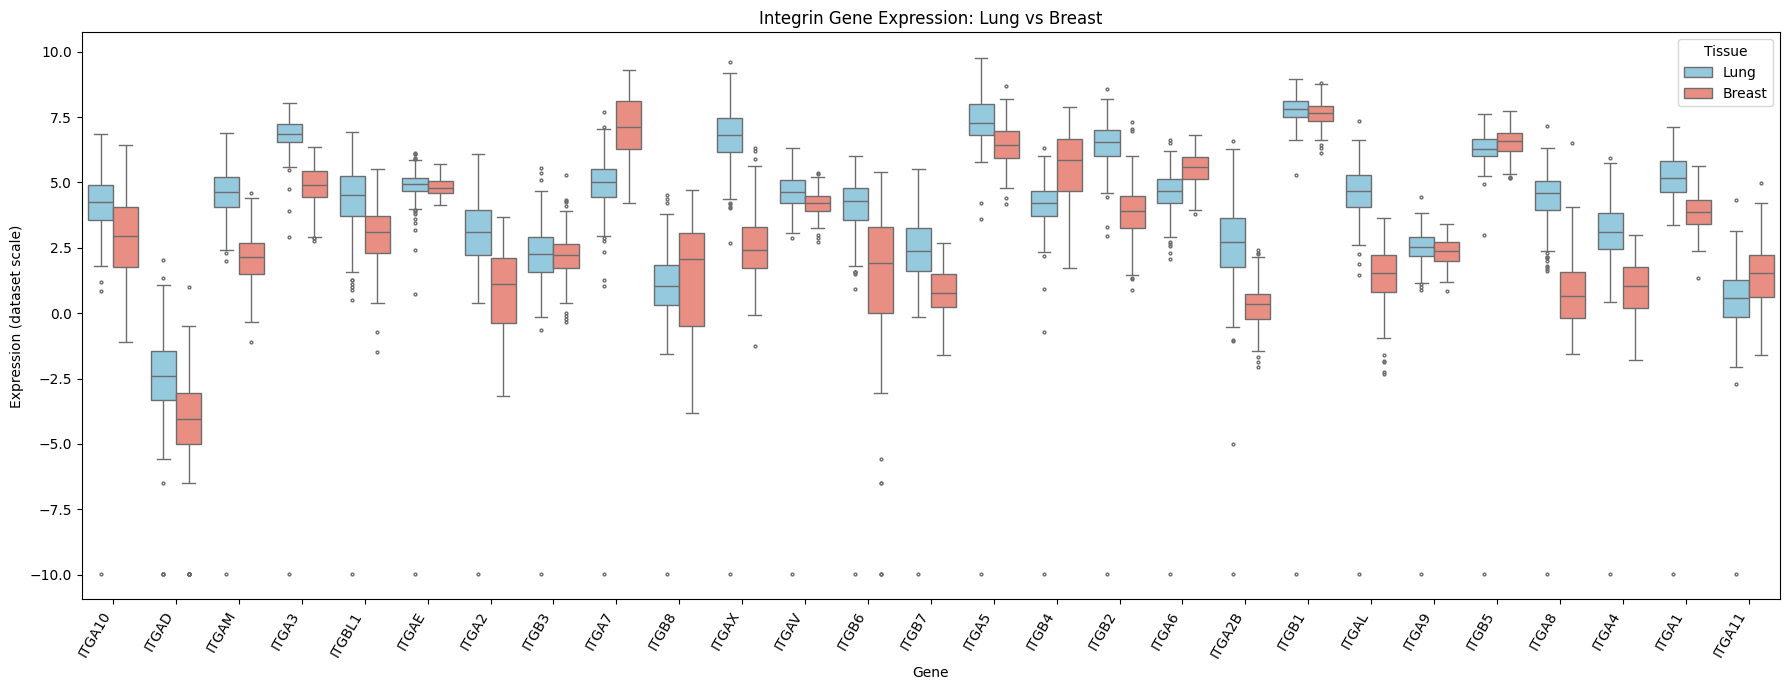

In [10]:
# Select the gene columns
gene_columns = [col for col in lung_breast.columns if col.startswith("ITG")]

# Reshape gene columns into Gene and Expression columns
long_data = lung_breast.melt(
    id_vars=["primary_site"],
    value_vars=gene_columns,
    var_name="Gene",
    value_name="Expression"
)

# Compare Lung and Breast for each gene
plt.figure(figsize=(18, 7))

sns.boxplot(
    data=long_data,
    x="Gene",
    y="Expression",
    hue="primary_site",
    hue_order=["Lung", "Breast"],
    palette={"Lung": "skyblue", "Breast": "salmon"},
    fliersize=2
)

plt.title("Integrin Gene Expression: Lung vs Breast")
plt.xlabel("Gene")
plt.ylabel("Expression (dataset scale)")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Tissue")
plt.tight_layout()
plt.savefig("lung_vs_breast_integrins.png", dpi=300)
plt.show()

,count,mean,median,std
primary_site,,,,
Breast,179,4.817,4.921,0.822
Lung,288,6.793,6.872,1.158


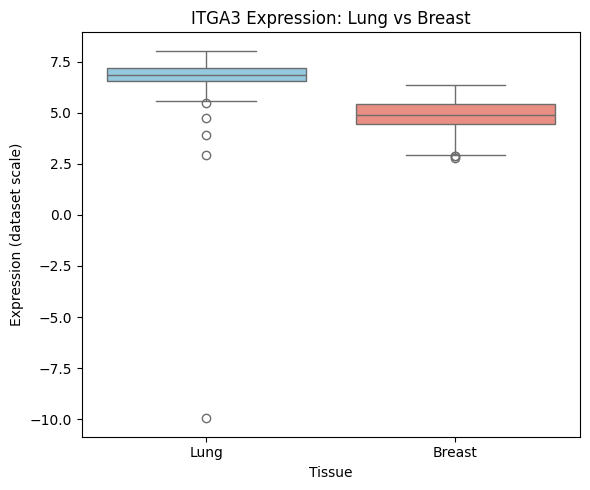

In [11]:
# Summarize ITGA3 expression for each tissue
summary = lung_breast.groupby("primary_site")["ITGA3"].agg(
    ["count", "mean", "median", "std"]
)
display(summary.round(3))

# Plot ITGA3 expression
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=lung_breast,
    x="primary_site",
    y="ITGA3",
    hue="primary_site",
    order=["Lung", "Breast"],
    palette={"Lung": "skyblue", "Breast": "salmon"}
)

plt.title("ITGA3 Expression: Lung vs Breast")
plt.xlabel("Tissue")
plt.ylabel("Expression (dataset scale)")
plt.tight_layout()
plt.savefig("ITGA3_lung_vs_breast.png", dpi=300)
plt.show()

Integrin expression patterns differed between Lung and Breast samples, with the direction of the difference depending on the gene. ITGA3 had higher median expression in Lung (6.872) than Breast (4.921) on the dataset’s expression scale. Mean expression was also higher in Lung (6.793) than Breast (4.817). Because integrins help cells interact with the extracellular matrix, these differences may reflect tissue-specific cell composition and adhesion functions. These descriptive plots do not establish statistical significance or show that higher gene expression causes greater protein activity.